In [1]:
import numpy as np
import networkx as nx
import trimesh


import pyvista as pv
import matplotlib.pyplot as plt

from src import vis

from src.stratified import Stratified

# Load an Example

In [2]:
loaded_mesh = trimesh.load("data/nm-mesh-iso.ply")
loaded_mesh = trimesh.load("data/drop-iso.ply")
#loaded_mesh = trimesh.load("data/drop.ply")

#loaded_mesh = trimesh.load("data/goats-004-2.obj")

vertices = loaded_mesh.vertices
faces = loaded_mesh.faces

print(vertices.shape, faces.shape)

(2448, 3) (4809, 3)


In [3]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.9)
pl.show()

Widget(value='<iframe src="http://localhost:36443/index.html?ui=P_0x7c402152cdd0_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


# Detect Strats

In [4]:
strats = Stratified(faces, vertices)

In [5]:
cmap = 'rainbow'
if strats.n_strats <= 20:
    cmap = 'tab20'
if strats.n_strats <= 10:
    cmap = 'tab10'

mesh = vis.get_pv_mesh(strats.vertices, strats.faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, scalars=strats.strats_labels, categories=True, cmap=cmap, smooth_shading=False, show_edges=True, opacity=1.0)

vis.add_graph_to_plotter(pl, strats.skeleton_graph, pos={node: strats.vertices[node] for node in strats.skeleton_graph.nodes()}, 
                         node_color='white', edge_color='white')
pl.show()

Widget(value='<iframe src="http://localhost:36443/index.html?ui=P_0x7c4099e0da90_1&reconnect=auto" class="pyvi…

In [6]:
strats.define_values_on_skeleton()

status: optimal
objective: 0.1851545394074652
n: [1 2 2 2]
s: 0.5069236596928197


array([0., 0., 0., ..., 0., 0., 0.], shape=(2448,))

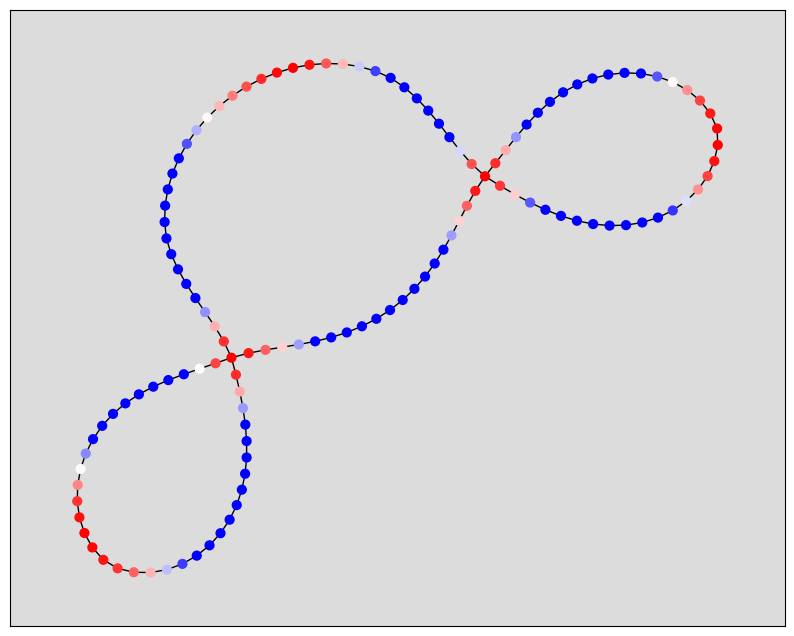

In [7]:
node_colors = plt.get_cmap('bwr')(strats.values[list(strats.skeleton_graph.nodes())])

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

nx.draw_networkx(strats.skeleton_graph, node_color=node_colors, ax=ax,
                 pos=nx.kamada_kawai_layout(strats.skeleton_graph), node_size=40, with_labels=False)
ax.set_facecolor('gainsboro')

plt.show()

In [8]:
pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, scalars=strats.values, categories=False, cmap='bwr', smooth_shading=False, show_edges=True, opacity=1.0)

pl.show()

Widget(value='<iframe src="http://localhost:36443/index.html?ui=P_0x7c3ff80ec470_2&reconnect=auto" class="pyvi…

In [ ]:
V, F, old2new, new2old = strats.get_stratum_parameters(0)

In [ ]:
mesh = vis.get_pv_mesh(V, F)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.9)
pl.show()

NameError: name 'V' is not defined

In [ ]:
import igl

In [ ]:
from src import triangletools


array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]], shape=(4809, 3))

In [ ]:
print(f'strats.vertices.shape = {strats.vertices.shape}')
print(f'strats.faces.shape = {strats.faces.shape}')

cut_mask = triangletools.edge_list_to_cut_mask(strats.faces, strats.skeleton_edges)
print(f'cut_mask.shape = {cut_mask.shape}')


V.shape = (9251, 3), strats.vertices.shape = (2448, 3), strats.skeleton_edges.shape = (129, 2)


In [ ]:
V, F, new2old = igl.cut_mesh(strats.vertices, strats.faces, cut_mask)


print(f'V.shape = {V.shape}, strats.vertices.shape = {strats.vertices.shape}, strats.skeleton_edges.shape = {strats.skeleton_edges.shape}')

In [ ]:
V.shape, strats.vertices.shape, strats.skeleton_edges.shape

((11422, 3), (2448, 3), (129, 2))

In [ ]:
new2old.max(), new2old.shape

(np.int64(11421), (11422,))

In [ ]:
import pandas as pd
pd.Series(new2old).value_counts()

3        9
1        7
12       7
13       7
15       7
        ..
11417    1
11418    1
11419    1
11420    1
11421    1
Name: count, Length: 11058, dtype: int64

In [ ]:
new2old

array([    0,     1,     2, ..., 11419, 11420, 11421],
      shape=(11422,), dtype=int64)